In [1]:
#	Find out accuracy levels of various machine learning techniques such as
#Support Vector Machines (SVM),
#K-Nearest Neighbor (KNN),
#Decision Trees (DT) ,
#Logistic Regression (LR) and
#Random Forest (RF).

In [2]:
#Data Visualization - Seaborn and Matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/content/cardio. csv", sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [6]:
df['age_years'] = df['age'] / 365.25
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.841205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52.676249
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61.878166
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52.199863
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61.412731


In [7]:
df = df.iloc[:, 2:]
df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,168,76.0,120,80,1,1,1,0,1,0,52.676249
69996,1,158,126.0,140,90,2,2,0,0,1,1,61.878166
69997,2,183,105.0,180,90,3,1,0,1,0,1,52.199863
69998,1,163,72.0,135,80,1,2,0,0,0,1,61.412731


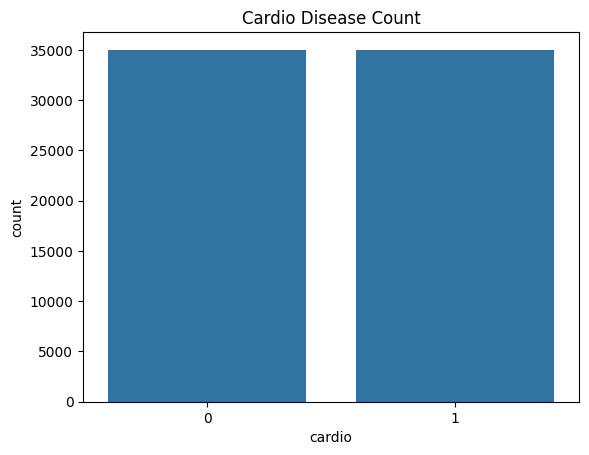

In [8]:
sns.countplot(x="cardio", data=df)
plt.title("Cardio Disease Count")
plt.show()
#To know how many people have cardio disease

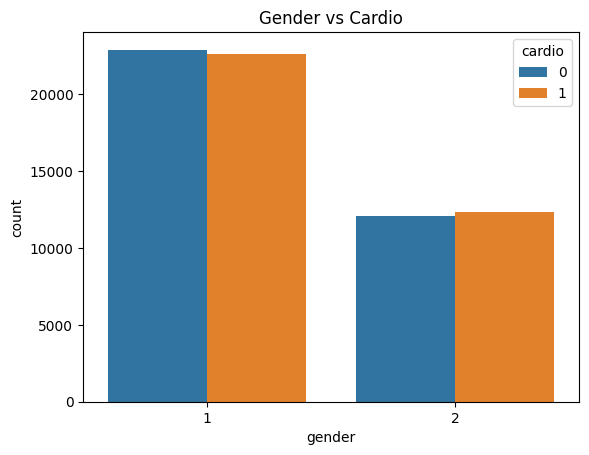

In [9]:
sns.countplot(x="gender", hue="cardio", data=df)
plt.title("Gender vs Cardio")
plt.show()
#To compare heart disease cases between male and female.

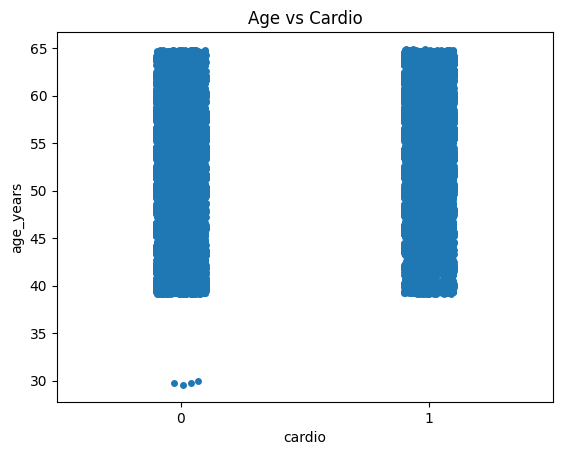

In [10]:
sns.stripplot(x="cardio", y="age_years", data=df, jitter=True)
plt.title("Age vs Cardio")
plt.show()
#To check whether cardio patients are mostly older.

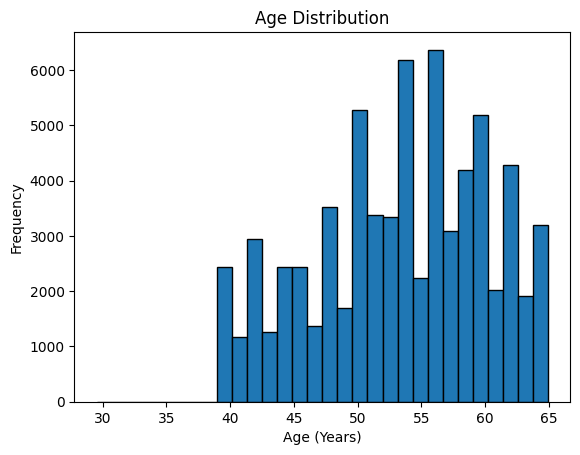

In [11]:
plt.hist(df["age_years"], bins=30, edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.show()

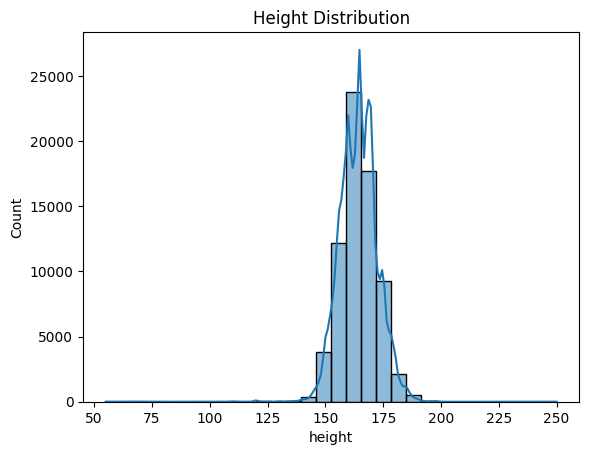

In [12]:
sns.histplot(df["height"], bins=30, kde=True)
plt.title("Height Distribution")
plt.show()

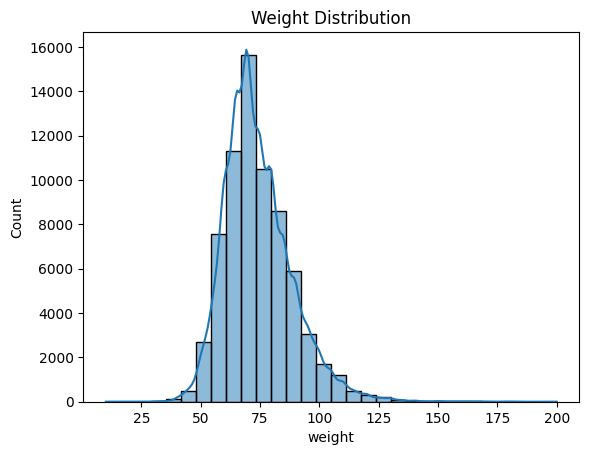

In [13]:
sns.histplot(df["weight"], bins=30, kde=True)
plt.title("Weight Distribution")
plt.show()

In [14]:
df = df[df["ap_hi"] > 0]
df = df[df["ap_lo"] > 0]
df = df[df["ap_hi"] < 250]
df = df[df["ap_lo"] < 200]
df = df[df["ap_hi"] > df["ap_lo"]]

df = df[(df["height"] > 120) & (df["height"] < 220)]
df = df[(df["weight"] > 30) & (df["weight"] < 200)]

In [15]:
# BMI calculation
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)
#BMI is used to check health condition related to body weight and helps to analyze cardio risk easily.

In [16]:
df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120
1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679
2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805
3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479
4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,168,76.0,120,80,1,1,1,0,1,0,52.676249,26.927438
69996,1,158,126.0,140,90,2,2,0,0,1,1,61.878166,50.472681
69997,2,183,105.0,180,90,3,1,0,1,0,1,52.199863,31.353579
69998,1,163,72.0,135,80,1,2,0,0,0,1,61.412731,27.099251


We use strip plot instead of scatter because:
*   categorical values have very few unique points
* scatter will overlap heavil
* strip plot shows data clearly using jitter  

So strip plot gives better visualization and meaningful insights.

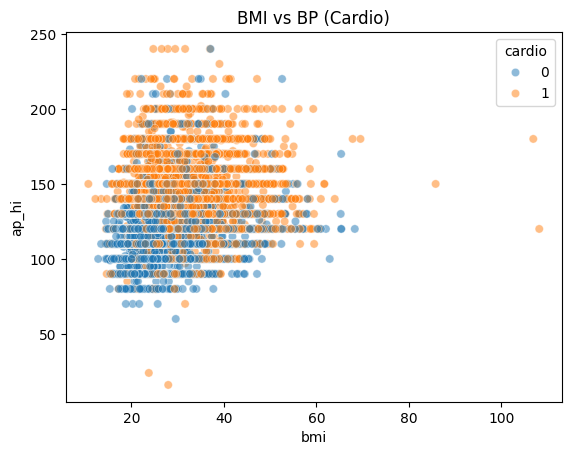

In [17]:
sns.scatterplot(x="bmi", y="ap_hi", hue="cardio", data=df, alpha=0.5)
plt.title("BMI vs BP (Cardio)")
plt.show()
#To check if higher BMI leads to higher BP and more cardio risk.

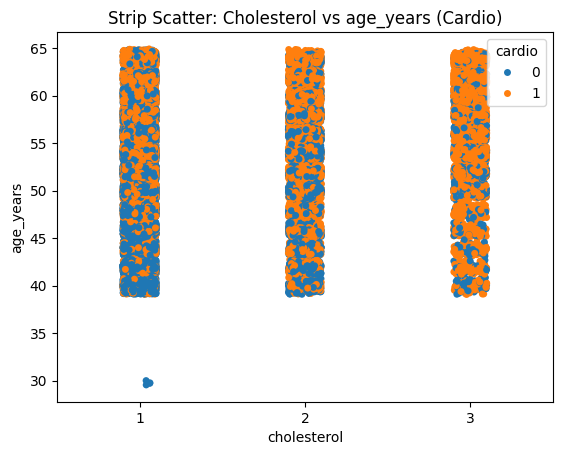

In [18]:
sns.stripplot(x="cholesterol", y="age_years", hue="cardio", data=df, jitter=True)
plt.title("Strip Scatter: Cholesterol vs age_years (Cardio)")
plt.show()

In [19]:
#more cardio=1 points in cholesterol=3 category
# Means high cholesterol people have more heart disease.
# Means cholesterol increases with age.

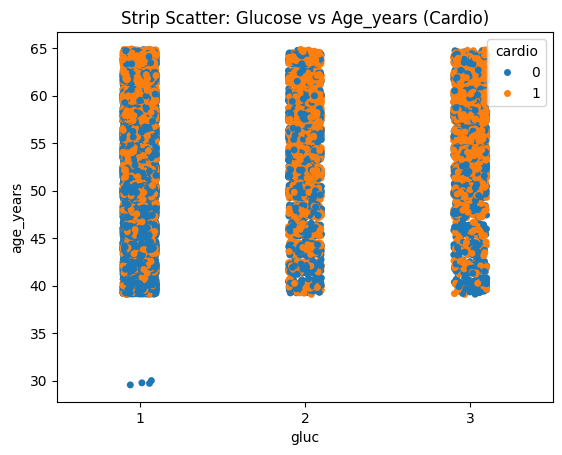

In [20]:
sns.stripplot(x="gluc", y="age_years", hue="cardio", data=df, jitter=True)
plt.title("Strip Scatter: Glucose vs Age_years (Cardio)")
plt.show()
# Higher glucose levels increase risk of cardiovascular disease.

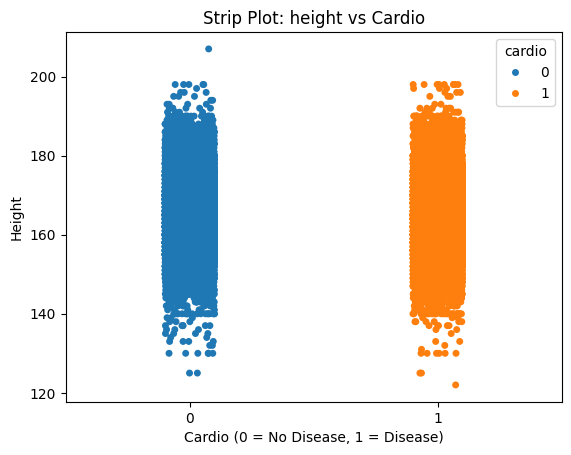

In [21]:
sns.stripplot(x="cardio", y="height", hue="cardio", data=df, jitter=True)
plt.title("Strip Plot: height vs Cardio")
plt.xlabel("Cardio (0 = No Disease, 1 = Disease)")
plt.ylabel("Height")
plt.show()

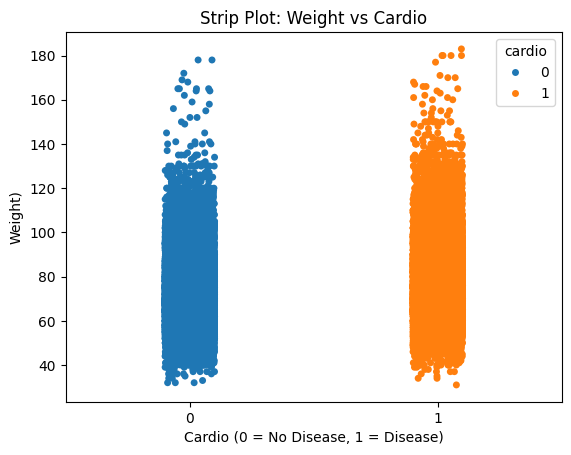

In [22]:
sns.stripplot(x="cardio", y="weight", hue="cardio", data=df, jitter=True)
plt.title("Strip Plot: Weight vs Cardio")
plt.xlabel("Cardio (0 = No Disease, 1 = Disease)")
plt.ylabel("Weight)")
plt.show()

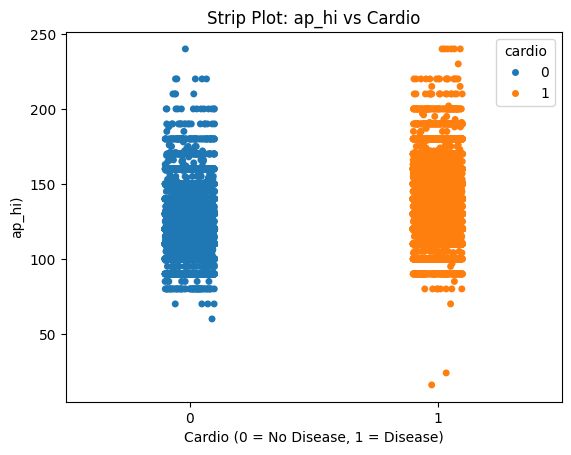

In [23]:
sns.stripplot(x="cardio", y="ap_hi", hue="cardio", data=df, jitter=True)
plt.title("Strip Plot: ap_hi vs Cardio")
plt.xlabel("Cardio (0 = No Disease, 1 = Disease)")
plt.ylabel("ap_hi)")
plt.show()

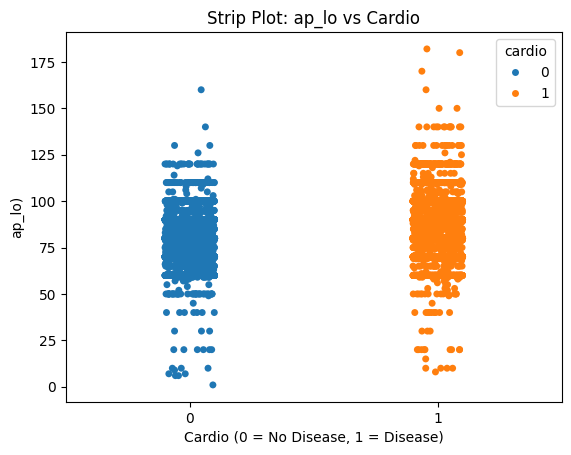

In [24]:
sns.stripplot(x="cardio", y="ap_lo", hue="cardio", data=df, jitter=True)
plt.title("Strip Plot: ap_lo vs Cardio")
plt.xlabel("Cardio (0 = No Disease, 1 = Disease)")
plt.ylabel("ap_lo)")
plt.show()

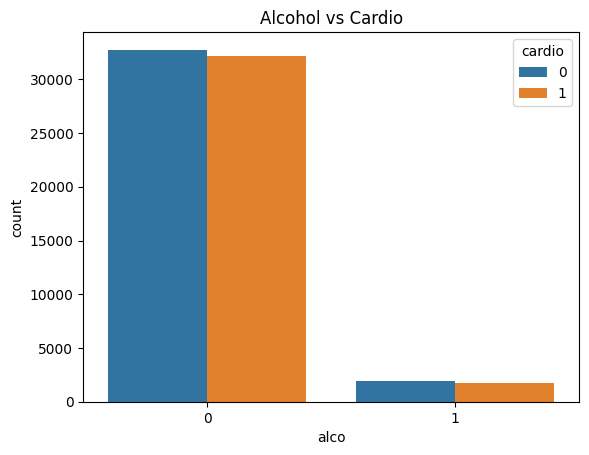

In [25]:
sns.countplot(x="alco", hue="cardio", data=df)
plt.title("Alcohol vs Cardio")
plt.show()

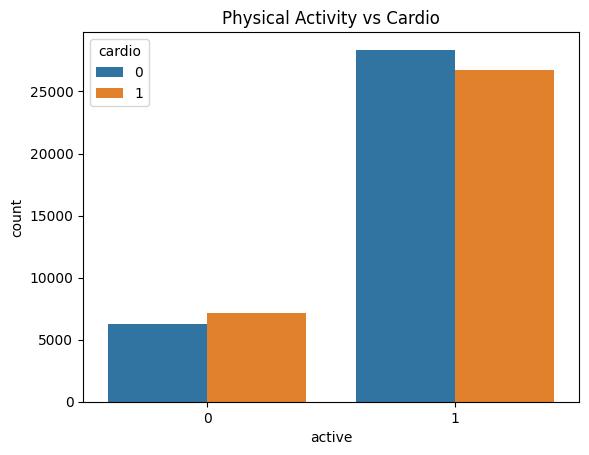

In [26]:
sns.countplot(x="active", hue="cardio", data=df)
plt.title("Physical Activity vs Cardio")
plt.show()
#Physically inactive people show higher chances of cardiovascular disease compared to active people.

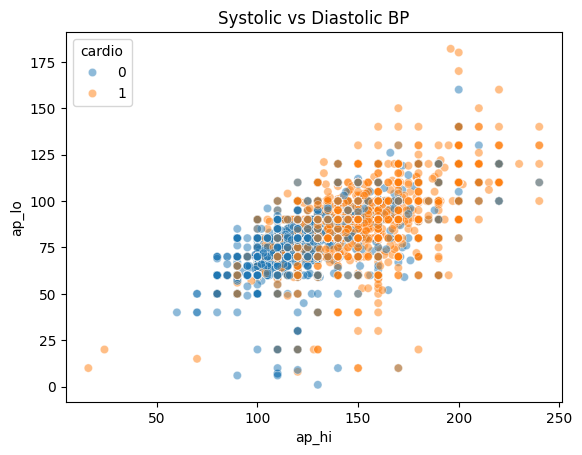

In [27]:
sns.scatterplot(x="ap_hi", y="ap_lo", hue="cardio", data=df, alpha=0.5)
plt.title("Systolic vs Diastolic BP")
plt.show()
#To analyze BP relationship and identify abnormal BP patients.

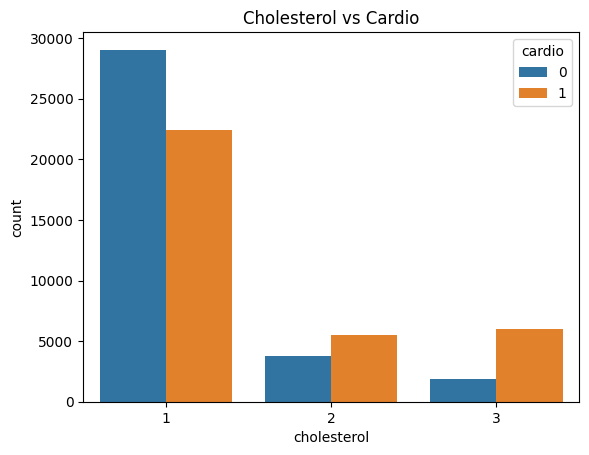

In [28]:
sns.countplot(x="cholesterol", hue="cardio", data=df)
plt.title("Cholesterol vs Cardio")
plt.show()
#To check whether high cholesterol increases heart disease risk.

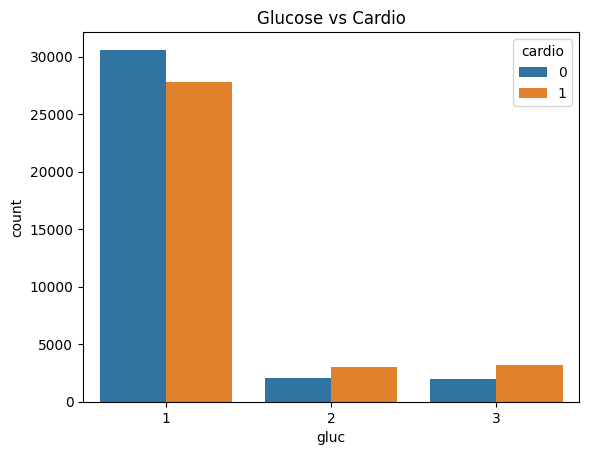

In [29]:
sns.countplot(x="gluc", hue="cardio", data=df)
plt.title("Glucose vs Cardio")
plt.show()
#To see effect of blood sugar level on cardio disease

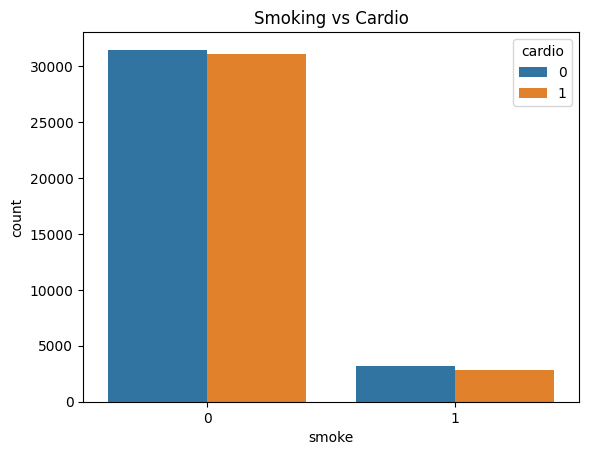

In [30]:
sns.countplot(x="smoke", hue="cardio", data=df)
plt.title("Smoking vs Cardio")
plt.show()
#To check whether smokers have higher heart disease count

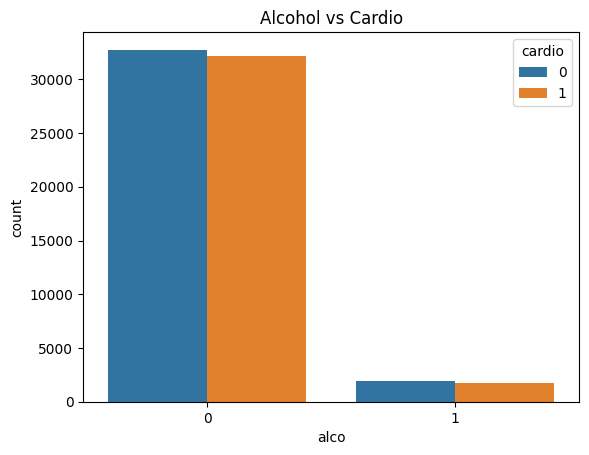

In [31]:
sns.countplot(x="alco", hue="cardio", data=df)
plt.title("Alcohol vs Cardio")
plt.show()
#To analyze relationship between alcohol consumption and cardio disease.

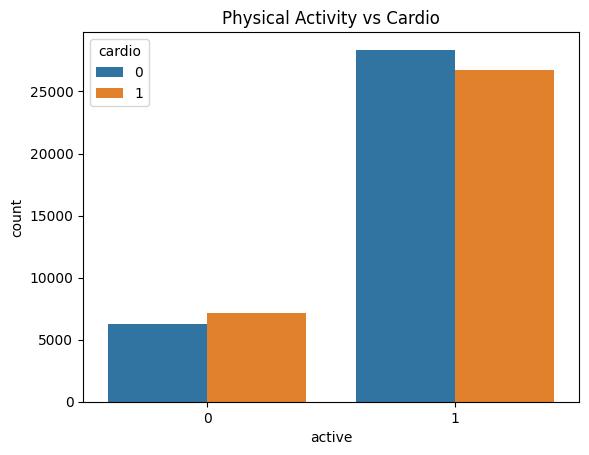

In [32]:
sns.countplot(x="active", hue="cardio", data=df)
plt.title("Physical Activity vs Cardio")
plt.show()
#To check if physical activity reduces cardio disease.

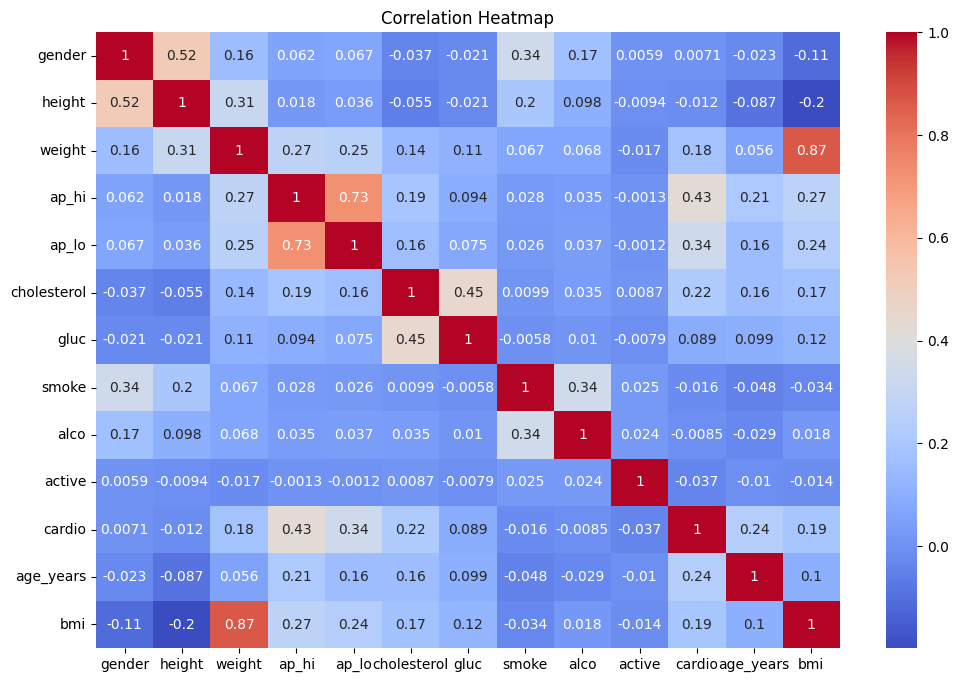

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
#To find which features are strongly related to cardio disease.

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define features (X) and target (y)
X = df.drop('cardio', axis=1)
y = df['cardio']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
lr = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
lr.fit(X_train_scaled, y_train)

# Make predictions and calculate accuracy
y_pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr*100)

Logistic Regression Accuracy: 72.76834511404212


In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", acc_knn*100)

KNN Accuracy: 70.15229905997231


In [36]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel="rbf")
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm*100)

SVM Accuracy: 73.16913211396925


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt*100)

Decision Tree Accuracy: 62.8944108431101


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf*100)

Random Forest Accuracy: 71.3473730233914


In [43]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120
1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679
2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805
3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479
4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,168,76.0,120,80,1,1,1,0,1,0,52.676249,26.927438
69996,1,158,126.0,140,90,2,2,0,0,1,1,61.878166,50.472681
69997,2,183,105.0,180,90,3,1,0,1,0,1,52.199863,31.353579
69998,1,163,72.0,135,80,1,2,0,0,0,1,61.412731,27.099251


In [42]:
# Features and Target

X = df.drop("cardio", axis=1)
y = df["cardio"]

In [44]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [45]:
# Scaling (Required for SVM)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
# Train SVM Model
svm_model = SVC(kernel="rbf")
svm_model.fit(X_train_scaled, y_train)

SVC()

In [53]:
#Accuracy

y_pred = svm_model.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, y_pred) * 100)

SVM Accuracy: 73.16913211396925


In [55]:
age_years = 45
gender = 2
height = 170
weight = 75
ap_hi = 140
ap_lo = 90
cholesterol = 2
gluc = 1
smoke = 0
alco = 0
active = 1

# BMI calculation
bmi = weight / ((height / 100) ** 2)

# New person data (same column order as dataset used for training)
# The 'id' column was dropped from the DataFrame before training.
new_person = [[
    gender, height, weight, ap_hi, ap_lo,
    cholesterol, gluc, smoke, alco, active,
    age_years, bmi
]]

# Scaling new input
new_person_scaled = scaler.transform(new_person)

# Prediction
result = svm_model.predict(new_person_scaled)

if result[0] == 1:
    print("Prediction: Person has Cardio Disease (Cardio = 1)")
else:
    print("Prediction: Person does NOT have Cardio Disease (Cardio = 0)")

Prediction: Person has Cardio Disease (Cardio = 1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [56]:
#Predict for new person
age_years = 45
gender = 2
height = 170
weight = 75
ap_hi = 140
ap_lo = 90
cholesterol = 2
gluc = 1
smoke = 0
alco = 0
active = 1

# BMI calculation
bmi = weight / ((height / 100) ** 2)

# New person data (same column order as dataset used for training)
# The 'id' column was dropped from the DataFrame before training.
new_person = [[
    gender, height, weight, ap_hi, ap_lo,
    cholesterol, gluc, smoke, alco, active,
    age_years, bmi
]]

# Scaling new input
new_person_scaled = scaler.transform(new_person)

# Prediction
result = svm_model.predict(new_person_scaled)

if result[0] == 1:
    print("Prediction: Person has Cardio Disease (Cardio = 1)")
else:
    print("Prediction: Person does NOT have Cardio Disease (Cardio = 0)")

Prediction: Person has Cardio Disease (Cardio = 1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
